In [1]:
# Importing libraries.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Loading master datasets.
japan = pd.read_csv("data/cleaned/japan_master.csv")
peers = pd.read_csv("data/cleaned/peer_comparison.csv")
topix = pd.read_csv("data/cleaned/topix_cleaned.csv")
topix = topix.rename(columns={'Year': 'Calendar_Year'})

# Setting consistent style.
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Defining governance reform milestone years for the reference lines.
milestones = {
    2013: "Abenomics",
    2015: "Gov. Code",
    2018: "Code Rev. 1",
    2021: "Code Rev. 2",
    2023: "TSE Push"
}

print("Datasets loaded:")
print(f"Japan master: {japan.shape}")
print(f"Peer comparison: {peers.shape}")
print(f"TOPIX: {topix.shape}")
print("\nJapan master columns:")
print(japan.columns.tolist())

Datasets loaded:
Japan master: (24, 14)
Peer comparison: (24, 17)
TOPIX: (26, 5)

Japan master columns:
['Calendar_Year', 'Capex_100M_Yen', 'Capex_Trillion_Yen', 'Dividends_100M_Yen', 'Dividends_Trillion_Yen', 'Earned_Surplus_100M_Yen', 'Earned_Surplus_Trillion_Yen', 'TOPIX_Year_End', 'TOPIX_Annual_High', 'TOPIX_Annual_Low', 'GDP_Constant_2015_USD', 'GDP_Per_Capita_Constant_2015_USD', 'Gross_Domestic_Savings_Pct_GDP', 'Gross_Fixed_Capital_Formation_Pct_GDP']


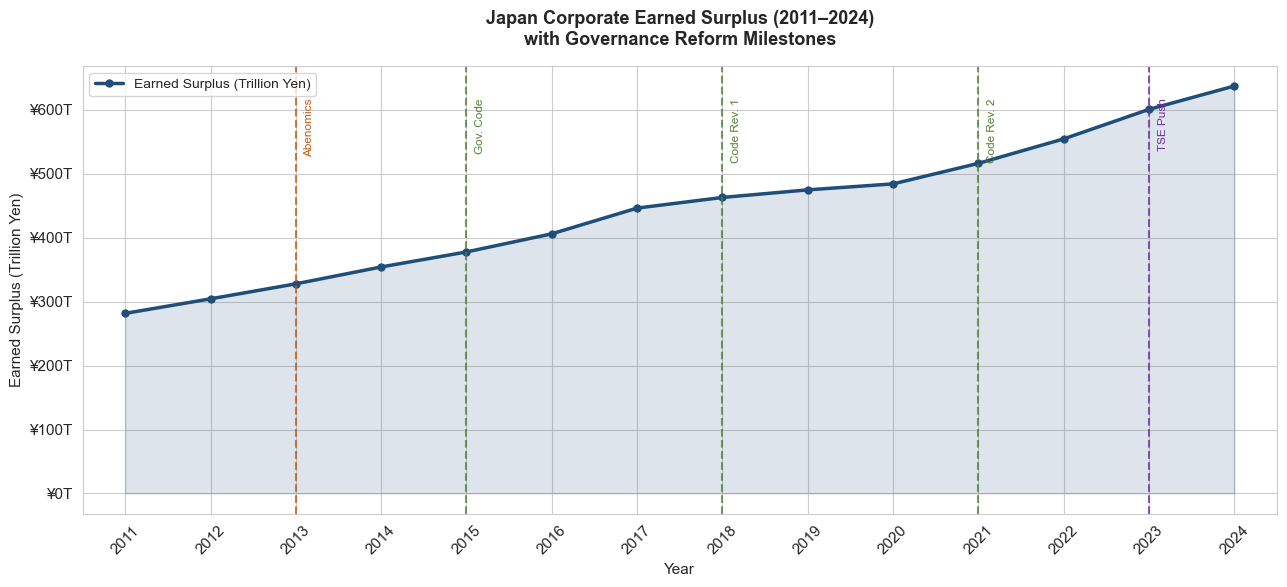

Chart 1 saved.


In [2]:
# Creating Chart 1: Earned Surplus Over Time.

fig, ax = plt.subplots(figsize=(13, 6))

# Filtering to years where surplus data exists.
surplus_data = japan.dropna(subset=['Earned_Surplus_Trillion_Yen'])

ax.plot(surplus_data['Calendar_Year'],
        surplus_data['Earned_Surplus_Trillion_Yen'],
        color='#1f4e79', linewidth=2.5, marker='o',
        markersize=5, label='Earned Surplus (Trillion Yen)')

# Shading area under the line.
ax.fill_between(surplus_data['Calendar_Year'],
                surplus_data['Earned_Surplus_Trillion_Yen'],
                alpha=0.15, color='#1f4e79')

# Adding governance milestones vertical lines.
milestone_colors = {
    2013: '#c55a11',
    2015: '#538135',
    2018: '#538135',
    2021: '#538135',
    2023: '#7030a0'
}

for year, label in milestones.items():
    if year >= surplus_data['Calendar_Year'].min():
        ax.axvline(x=year, color=milestone_colors[year],
                   linestyle='--', linewidth=1.5, alpha=0.8)
        ax.text(year + 0.1, surplus_data['Earned_Surplus_Trillion_Yen'].max() * 0.97,
                label, fontsize=8.5, color=milestone_colors[year],
                rotation=90, va='top')

# Formatting texts.
ax.set_title("Japan Corporate Earned Surplus (2011–2024)\nwith Governance Reform Milestones",
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Earned Surplus (Trillion Yen)", fontsize=11)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'¥{x:.0f}T'))
ax.set_xlim(surplus_data['Calendar_Year'].min() - 0.5,
            surplus_data['Calendar_Year'].max() + 0.5)
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.xticks(rotation=45)
ax.legend(loc='upper left', fontsize=10)

plt.tight_layout()
plt.savefig("data/charts/chart01_earned_surplus.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved.")

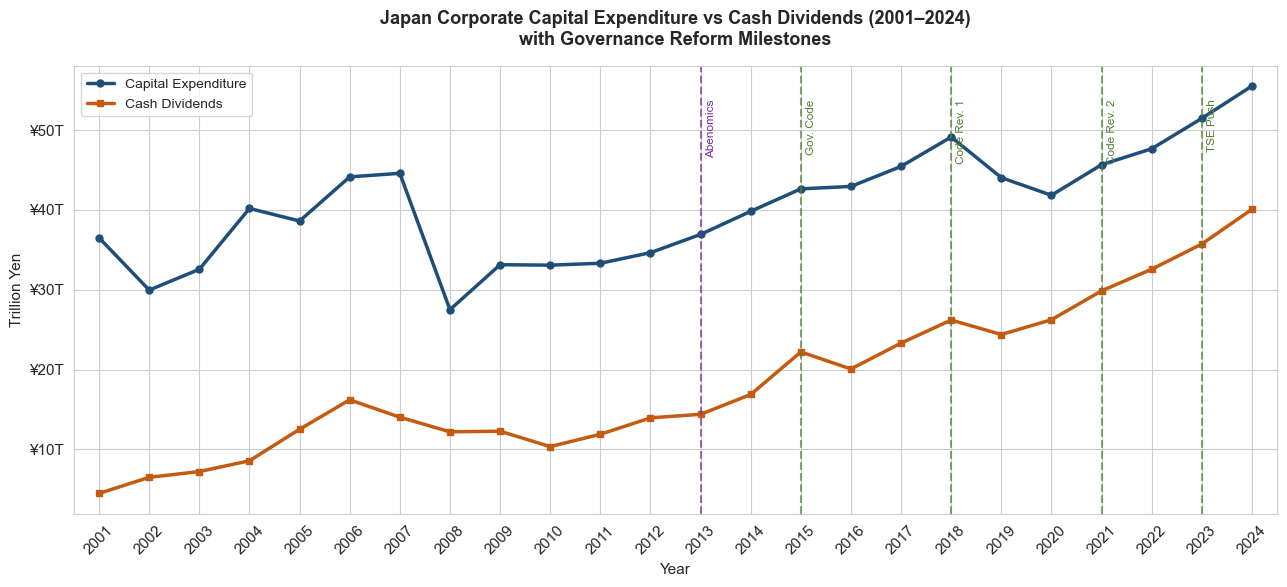

Chart 2 saved.


In [3]:
# Creating Chart 2: Capex vs Dividends Over Time.

fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(japan['Calendar_Year'],
        japan['Capex_Trillion_Yen'],
        color='#1f4e79', linewidth=2.5, marker='o',
        markersize=5, label='Capital Expenditure')

ax.plot(japan['Calendar_Year'],
        japan['Dividends_Trillion_Yen'],
        color='#c55a11', linewidth=2.5, marker='s',
        markersize=5, label='Cash Dividends')

# Adding governance milestones vertical lines.
for year, label in milestones.items():
    ax.axvline(x=year, color='#538135' if year != 2013 else '#7030a0',
               linestyle='--', linewidth=1.5, alpha=0.7)
    ax.text(year + 0.1,
            japan['Capex_Trillion_Yen'].max() * 0.97,
            label, fontsize=8.5,
            color='#538135' if year != 2013 else '#7030a0',
            rotation=90, va='top')

# Formatting texts.
ax.set_title("Japan Corporate Capital Expenditure vs Cash Dividends (2001–2024)\n"
             "with Governance Reform Milestones",
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Trillion Yen", fontsize=11)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'¥{x:.0f}T'))
ax.set_xlim(japan['Calendar_Year'].min() - 0.5,
            japan['Calendar_Year'].max() + 0.5)
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.xticks(rotation=45)
ax.legend(loc='upper left', fontsize=10)

plt.tight_layout()
plt.savefig("data/charts/chart02_capex_vs_dividends.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved.")

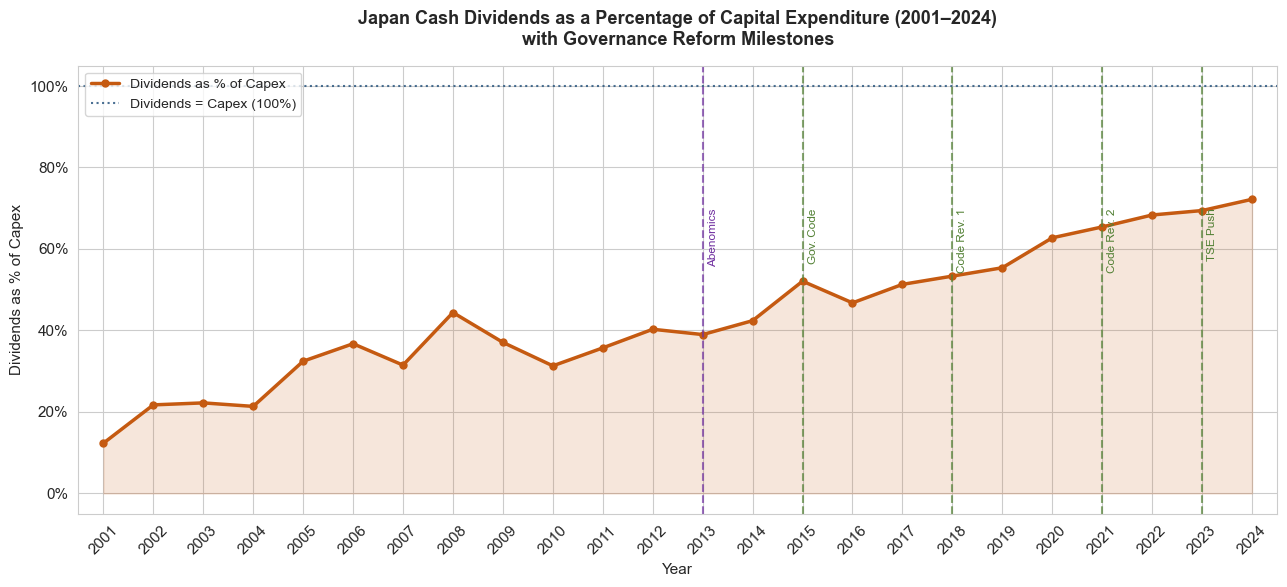

Chart 3 saved.

Dividends as % of Capex — selected years:
 Calendar_Year  Dividends_Pct_of_Capex
          2001                   12.32
          2007                   31.49
          2013                   38.99
          2015                   52.09
          2018                   53.34
          2021                   65.41
          2023                   69.43
          2024                   72.19


In [4]:
# Creating Chart 3: Dividends as percentage of CapEx.

japan['Dividends_Pct_of_Capex'] = (
    japan['Dividends_100M_Yen'] / 
    japan['Capex_100M_Yen'] * 100).round(2)

fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(japan['Calendar_Year'],
        japan['Dividends_Pct_of_Capex'],
        color='#c55a11', linewidth=2.5, marker='o',
        markersize=5, label='Dividends as % of Capex')

ax.fill_between(japan['Calendar_Year'],
                japan['Dividends_Pct_of_Capex'],
                alpha=0.15, color='#c55a11')

# Adding 100% reference line for comparison to rising CapEx values.
ax.axhline(y=100, color='#1f4e79', linestyle=':',
           linewidth=1.5, alpha=0.8,
           label='Dividends = Capex (100%)')

# Adding governance milestones vertical lines.
for year, label in milestones.items():
    ax.axvline(x=year,
               color='#538135' if year != 2013 else '#7030a0',
               linestyle='--', linewidth=1.5, alpha=0.7)
    ax.text(year + 0.1,
            japan['Dividends_Pct_of_Capex'].max() * 0.97,
            label, fontsize=8.5,
            color='#538135' if year != 2013 else '#7030a0',
            rotation=90, va='top')

# Formatting texts.
ax.set_title("Japan Cash Dividends as a Percentage of Capital Expenditure (2001–2024)\n"
             "with Governance Reform Milestones",
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Dividends as % of Capex", fontsize=11)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.set_xlim(japan['Calendar_Year'].min() - 0.5,
            japan['Calendar_Year'].max() + 0.5)
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.xticks(rotation=45)
ax.legend(loc='upper left', fontsize=10)

plt.tight_layout()
plt.savefig("data/charts/chart03_dividends_pct_capex.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 saved.")

# Printing key values for reference.
print("\nDividends as % of Capex — selected years:")
key_years = [2001, 2007, 2013, 2015, 2018, 2021, 2023, 2024]
print(japan[japan['Calendar_Year'].isin(key_years)][
    ['Calendar_Year', 'Dividends_Pct_of_Capex']].to_string(index=False))

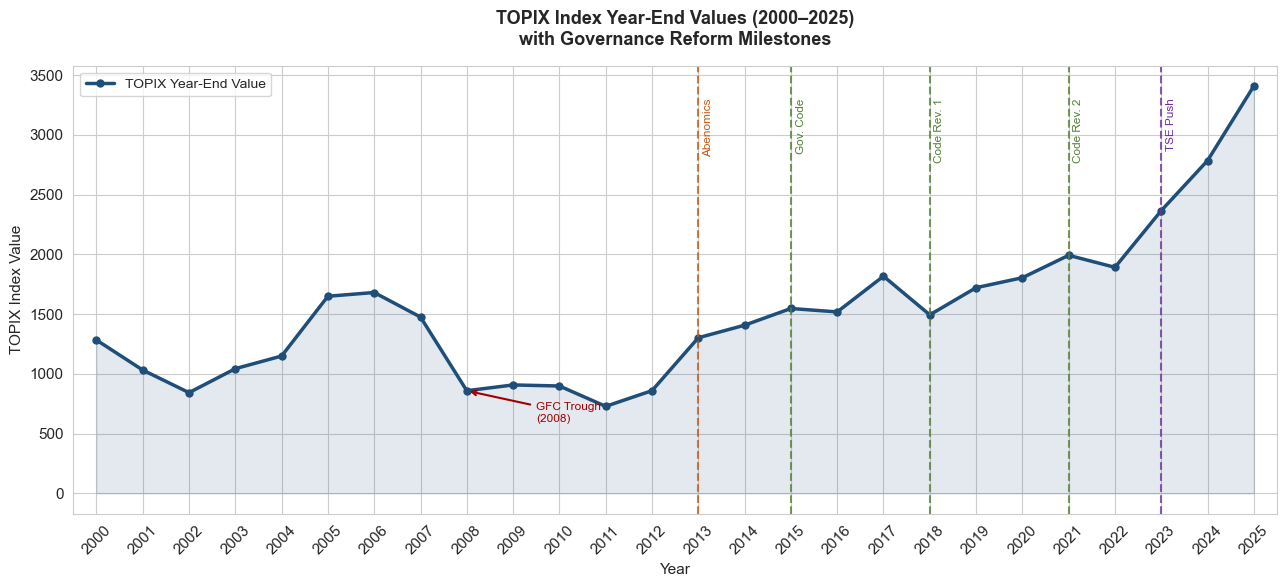

Chart 4 saved.

TOPIX year-end values at governance milestones:
 Calendar_Year  TOPIX_Year_End
          2012          859.80
          2013         1302.29
          2014         1407.51
          2015         1547.30
          2017         1817.56
          2018         1494.09
          2020         1804.68
          2021         1992.33
          2022         1891.71
          2023         2366.39
          2024         2784.92
          2025         3408.97


In [5]:
# Creating Chart 4: TOPIX Index Over Time with Governance Milestones.

# Using entire TOPIX dataset, including 2000 and 2025.
topix_plot = topix[topix['Calendar_Year'].between(2000, 2025)].copy()

fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(topix_plot['Calendar_Year'],
        topix_plot['TOPIX_Year_End'],
        color='#1f4e79', linewidth=2.5, marker='o',
        markersize=5, label='TOPIX Year-End Value')

ax.fill_between(topix_plot['Calendar_Year'],
                topix_plot['TOPIX_Year_End'],
                alpha=0.12, color='#1f4e79')

# Adding governance milestones vertical lines.
milestone_colors_full = {
    2013: '#c55a11',
    2015: '#538135',
    2018: '#538135',
    2021: '#538135',
    2023: '#7030a0'
}

for year, label in milestones.items():
    ax.axvline(x=year,
               color=milestone_colors_full[year],
               linestyle='--', linewidth=1.5, alpha=0.8)
    ax.text(year + 0.1,
            topix_plot['TOPIX_Year_End'].max() * 0.97,
            label, fontsize=8.5,
            color=milestone_colors_full[year],
            rotation=90, va='top')

# Annotating the 2008 financial crisis trough.
ax.annotate('GFC Trough\n(2008)',
            xy=(2008, 859),
            xytext=(2009.5, 600),
            fontsize=8.5,
            color='#a00000',
            arrowprops=dict(arrowstyle='->', color='#a00000',
                           lw=1.5))

# Formatting texts.
ax.set_title("TOPIX Index Year-End Values (2000–2025)\n"
             "with Governance Reform Milestones",
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("TOPIX Index Value", fontsize=11)
ax.set_xlim(topix_plot['Calendar_Year'].min() - 0.5,
            topix_plot['Calendar_Year'].max() + 0.5)
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.xticks(rotation=45)
ax.legend(loc='upper left', fontsize=10)

plt.tight_layout()
plt.savefig("data/charts/chart04_topix_milestones.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 4 saved.")

# Printing TOPIX values at each milestone year.
print("\nTOPIX year-end values at governance milestones:")
milestone_years = [2012, 2013, 2014, 2015, 2017, 2018,
                   2020, 2021, 2022, 2023, 2024, 2025]
print(topix[topix['Calendar_Year'].isin(milestone_years)][
    ['Calendar_Year', 'TOPIX_Year_End']].to_string(index=False))

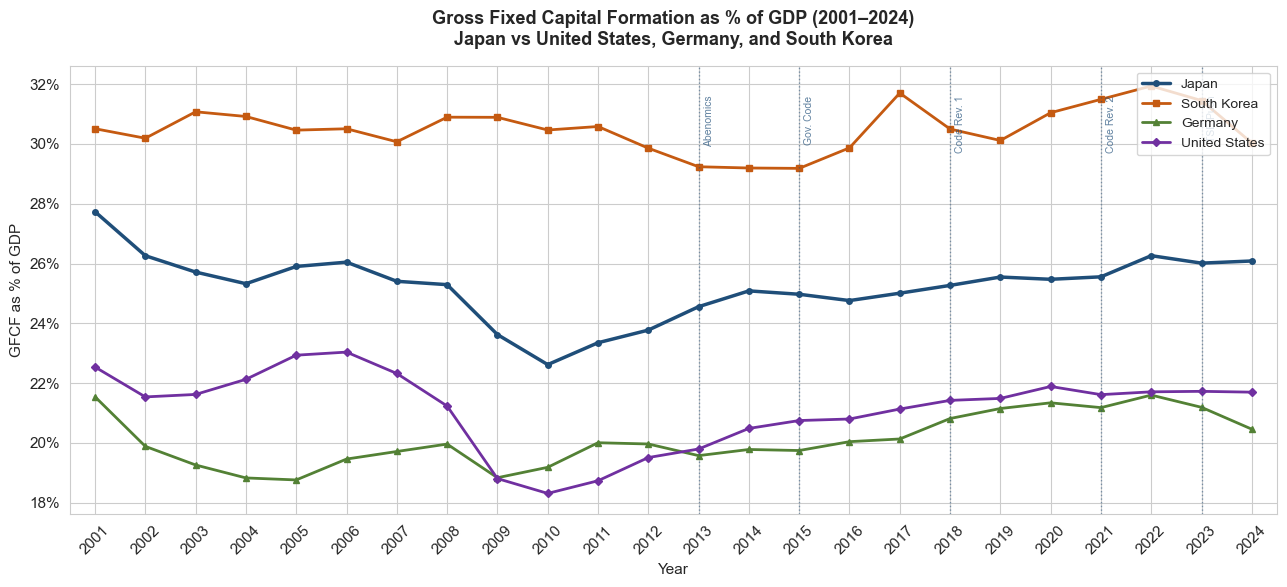

Chart 5 saved.

GFCF % of GDP at key years:
 Calendar_Year  Japan_GFCF_Pct_GDP  Germany_GFCF_Pct_GDP  Korea_GFCF_Pct_GDP  USA_GFCF_Pct_GDP
          2001           27.730973             21.543363           30.505835         22.538507
          2008           25.292816             19.963040           30.891752         21.235478
          2013           24.556527             19.577147           29.234861         19.798398
          2015           24.971456             19.747751           29.180084         20.750224
          2020           25.471698             21.342676           31.040908         21.888724
          2023           26.012088             21.191688           31.447015         21.726498
          2024           26.084090             20.460317           30.029371         21.698757


In [6]:
# Creating Chart 5: Gross Fixed Capital Formation % GDP.

fig, ax = plt.subplots(figsize=(13, 6))

country_config = {
    'Japan_GFCF_Pct_GDP':   ('#1f4e79', 'o', 'Japan', 2.5),
    'Korea_GFCF_Pct_GDP':   ('#c55a11', 's', 'South Korea', 2.0),
    'Germany_GFCF_Pct_GDP': ('#538135', '^', 'Germany', 2.0),
    'USA_GFCF_Pct_GDP':     ('#7030a0', 'D', 'United States', 2.0)
}

for col, (color, marker, label, lw) in country_config.items():
    ax.plot(peers['Calendar_Year'],
            peers[col],
            color=color, linewidth=lw,
            marker=marker, markersize=4,
            label=label)

# Adding governance milestones vertical lines for Japan context.
for year, label in milestones.items():
    ax.axvline(x=year, color='#1f4e79',
               linestyle=':', linewidth=1.0, alpha=0.5)
    ax.text(year + 0.1,
            peers['Korea_GFCF_Pct_GDP'].max() * 0.99,
            label, fontsize=7.5,
            color='#1f4e79',
            rotation=90, va='top', alpha=0.7)

# Formatting texts.
ax.set_title("Gross Fixed Capital Formation as % of GDP (2001–2024)\n"
             "Japan vs United States, Germany, and South Korea",
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("GFCF as % of GDP", fontsize=11)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.set_xlim(peers['Calendar_Year'].min() - 0.5,
            peers['Calendar_Year'].max() + 0.5)
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.xticks(rotation=45)
ax.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.savefig("data/charts/chart05_peer_gfcf_comparison.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 5 saved.")

# Printing 2001, 2013, 2015, 2023, and 2024 comparison values for all countries.
print("\nGFCF % of GDP at key years:")
key_years = [2001, 2008, 2013, 2015, 2020, 2023, 2024]
print(peers[peers['Calendar_Year'].isin(key_years)][
    ['Calendar_Year', 'Japan_GFCF_Pct_GDP', 'Germany_GFCF_Pct_GDP',
     'Korea_GFCF_Pct_GDP', 'USA_GFCF_Pct_GDP']].to_string(index=False))

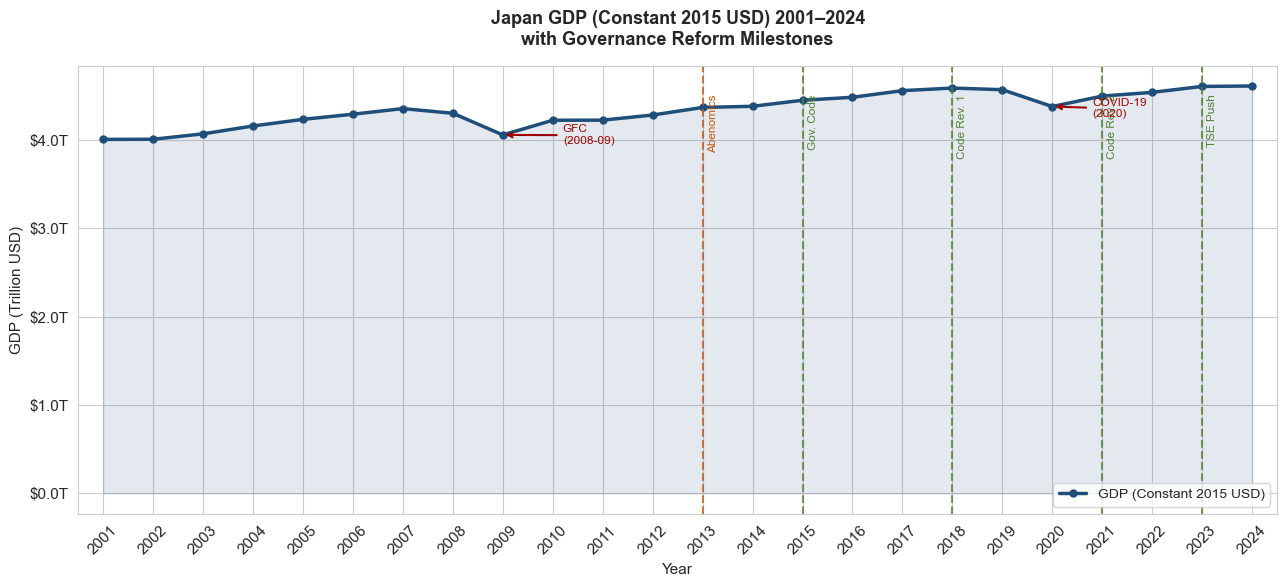

Chart 6 saved.

Japan GDP at key years (Trillion USD, constant 2015):
 Calendar_Year  GDP_Trillion_USD
          2001             4.002
          2008             4.297
          2009             4.053
          2013             4.364
          2015             4.445
          2020             4.374
          2021             4.492
          2023             4.601
          2024             4.606


In [7]:
# Creating Chart 6: Japan GDP Constant 2015 USD Over Time.

fig, ax = plt.subplots(figsize=(13, 6))

# Converting to trillions USD for readability and cross-analysis compatibility.
japan['GDP_Trillion_USD'] = japan['GDP_Constant_2015_USD'] / 1e12

ax.plot(japan['Calendar_Year'],
        japan['GDP_Trillion_USD'],
        color='#1f4e79', linewidth=2.5, marker='o',
        markersize=5, label='GDP (Constant 2015 USD)')

ax.fill_between(japan['Calendar_Year'],
                japan['GDP_Trillion_USD'],
                alpha=0.12, color='#1f4e79')

# Adding governance milestones vertical lines.
for year, label in milestones.items():
    ax.axvline(x=year,
               color='#c55a11' if year == 2013 else '#538135',
               linestyle='--', linewidth=1.5, alpha=0.8)
    ax.text(year + 0.1,
            japan['GDP_Trillion_USD'].max() * 0.98,
            label, fontsize=8.5,
            color='#c55a11' if year == 2013 else '#538135',
            rotation=90, va='top')

# Annotating key events.
ax.annotate('GFC\n(2008-09)',
            xy=(2009, 4.053),
            xytext=(2010.2, 3.95),
            fontsize=8.5, color='#a00000',
            arrowprops=dict(arrowstyle='->',
                           color='#a00000', lw=1.5))

ax.annotate('COVID-19\n(2020)',
            xy=(2020, 4.374),
            xytext=(2020.8, 4.25),
            fontsize=8.5, color='#a00000',
            arrowprops=dict(arrowstyle='->',
                           color='#a00000', lw=1.5))

# Formatting texts.
ax.set_title("Japan GDP (Constant 2015 USD) 2001–2024\n"
             "with Governance Reform Milestones",
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("GDP (Trillion USD)", fontsize=11)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x:.1f}T'))
ax.set_xlim(japan['Calendar_Year'].min() - 0.5,
            japan['Calendar_Year'].max() + 0.5)
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.xticks(rotation=45)
ax.legend(loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig("data/charts/chart06_japan_gdp.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 6 saved.")

# Printing GDP values at key years.
print("\nJapan GDP at key years (Trillion USD, constant 2015):")
key_years = [2001, 2008, 2009, 2013, 2015, 2020, 2021, 2023, 2024]
print(japan[japan['Calendar_Year'].isin(key_years)][
    ['Calendar_Year', 'GDP_Trillion_USD']].round(3).to_string(index=False))

In [8]:
# Calculating overall GDP growth across the analytical period (2001-2024)
gdp_2001 = japan.loc[japan['Calendar_Year'] == 2001, 
                      'GDP_Trillion_USD'].values[0]
gdp_2024 = japan.loc[japan['Calendar_Year'] == 2024, 
                      'GDP_Trillion_USD'].values[0]
gdp_growth = ((gdp_2024 / gdp_2001) - 1) * 100

print(f"Japan GDP 2001: ${gdp_2001:.3f}T")
print(f"Japan GDP 2024: ${gdp_2024:.3f}T")
print(f"Total real GDP growth 2001-2024: {gdp_growth:.1f}%")

# Comparing to capex growth over same period.
capex_2001 = japan.loc[japan['Calendar_Year'] == 2001,
                        'Capex_Trillion_Yen'].values[0]
capex_2024 = japan.loc[japan['Calendar_Year'] == 2024,
                        'Capex_Trillion_Yen'].values[0]
capex_growth = ((capex_2024 / capex_2001) - 1) * 100

print(f"\nJapan Capex 2001: ¥{capex_2001:.1f}T")
print(f"Japan Capex 2024: ¥{capex_2024:.1f}T")
print(f"Total capex growth 2001-2024: {capex_growth:.1f}%")

print(f"\nKey insight: Capex grew {capex_growth:.1f}% while")
print(f"real GDP grew only {gdp_growth:.1f}% over the same period.")

Japan GDP 2001: $4.002T
Japan GDP 2024: $4.606T
Total real GDP growth 2001-2024: 15.1%

Japan Capex 2001: ¥36.5T
Japan Capex 2024: ¥55.5T
Total capex growth 2001-2024: 52.1%

Key insight: Capex grew 52.1% while
real GDP grew only 15.1% over the same period.


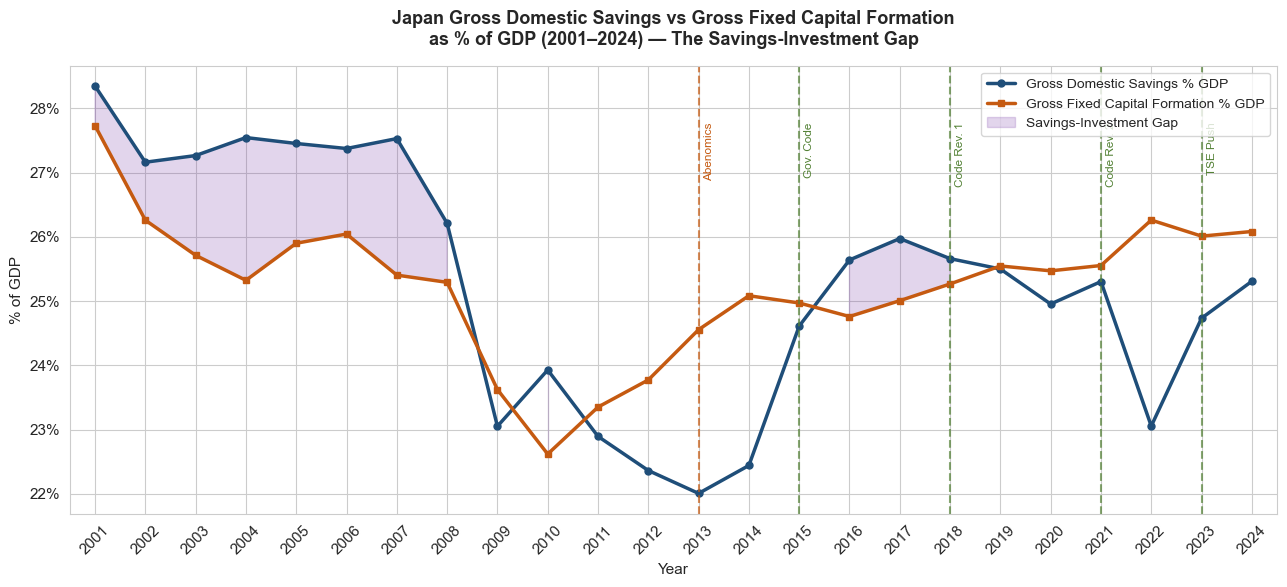

Chart 7 saved.

Savings-Investment Gap at key years (percentage points):
 Calendar_Year  Gross_Domestic_Savings_Pct_GDP  Gross_Fixed_Capital_Formation_Pct_GDP  Savings_Investment_Gap_Pct
          2001                       28.348950                              27.730973                        0.62
          2005                       27.454163                              25.901044                        1.55
          2008                       26.211171                              25.292816                        0.92
          2013                       22.007169                              24.556527                       -2.55
          2015                       24.611459                              24.971456                       -0.36
          2018                       25.661674                              25.267768                        0.39
          2020                       24.955174                              25.471698                       -0.52
          2023 

In [9]:
# Creating Chart 7: Gross Domestic Savings vs GFCF % of GDP for Japan.

fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(japan['Calendar_Year'],
        japan['Gross_Domestic_Savings_Pct_GDP'],
        color='#1f4e79', linewidth=2.5, marker='o',
        markersize=5, label='Gross Domestic Savings % GDP')

ax.plot(japan['Calendar_Year'],
        japan['Gross_Fixed_Capital_Formation_Pct_GDP'],
        color='#c55a11', linewidth=2.5, marker='s',
        markersize=5, label='Gross Fixed Capital Formation % GDP')

# Shading gap between savings and investment.
ax.fill_between(japan['Calendar_Year'],
                japan['Gross_Domestic_Savings_Pct_GDP'],
                japan['Gross_Fixed_Capital_Formation_Pct_GDP'],
                where=japan['Gross_Domestic_Savings_Pct_GDP'] >=
                      japan['Gross_Fixed_Capital_Formation_Pct_GDP'],
                alpha=0.2, color='#7030a0',
                label='Savings-Investment Gap')

# Adding governance milestones vertical lines.
for year, label in milestones.items():
    ax.axvline(x=year,
               color='#538135' if year != 2013 else '#c55a11',
               linestyle='--', linewidth=1.5, alpha=0.7)
    ax.text(year + 0.1,
            japan['Gross_Domestic_Savings_Pct_GDP'].max() * 0.98,
            label, fontsize=8.5,
            color='#538135' if year != 2013 else '#c55a11',
            rotation=90, va='top')

# Formatting texts.
ax.set_title("Japan Gross Domestic Savings vs Gross Fixed Capital Formation\n"
             "as % of GDP (2001–2024) — The Savings-Investment Gap",
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("% of GDP", fontsize=11)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.set_xlim(japan['Calendar_Year'].min() - 0.5,
            japan['Calendar_Year'].max() + 0.5)
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.xticks(rotation=45)
ax.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.savefig("data/charts/chart07_savings_investment_gap.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 7 saved.")

# Calculating gap at key years.
japan['Savings_Investment_Gap_Pct'] = (
    japan['Gross_Domestic_Savings_Pct_GDP'] -
    japan['Gross_Fixed_Capital_Formation_Pct_GDP']).round(2)

print("\nSavings-Investment Gap at key years (percentage points):")
key_years = [2001, 2005, 2008, 2013, 2015, 2018, 2020, 2023, 2024]
print(japan[japan['Calendar_Year'].isin(key_years)][
    ['Calendar_Year', 'Gross_Domestic_Savings_Pct_GDP',
     'Gross_Fixed_Capital_Formation_Pct_GDP',
     'Savings_Investment_Gap_Pct']].to_string(index=False))

In [10]:
print("Japan columns:", japan.columns.tolist())
print("Shape:", japan.shape)

Japan columns: ['Calendar_Year', 'Capex_100M_Yen', 'Capex_Trillion_Yen', 'Dividends_100M_Yen', 'Dividends_Trillion_Yen', 'Earned_Surplus_100M_Yen', 'Earned_Surplus_Trillion_Yen', 'TOPIX_Year_End', 'TOPIX_Annual_High', 'TOPIX_Annual_Low', 'GDP_Constant_2015_USD', 'GDP_Per_Capita_Constant_2015_USD', 'Gross_Domestic_Savings_Pct_GDP', 'Gross_Fixed_Capital_Formation_Pct_GDP', 'Dividends_Pct_of_Capex', 'GDP_Trillion_USD', 'Savings_Investment_Gap_Pct']
Shape: (24, 17)


Pearson correlation — Capex vs TOPIX: 0.9128
P-value: 0.000000
Statistically significant (p<0.05): True


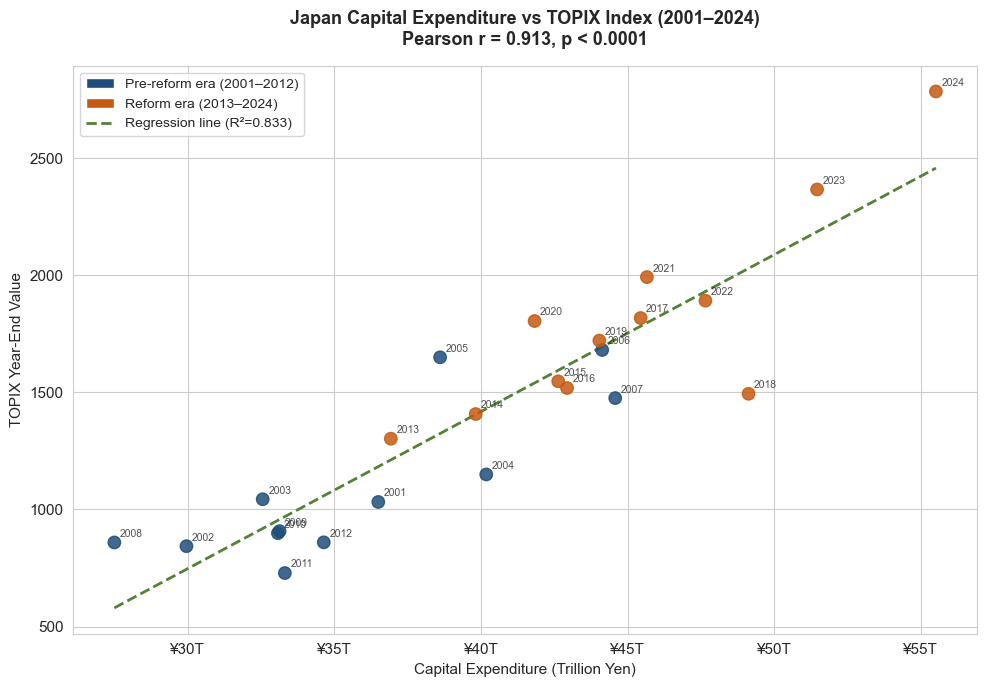

Chart 8 saved.


In [11]:
# Creating Chart 8: Scatter plot for TOPIX vs Capex with correlation.

from scipy import stats

japan_corr = japan.dropna(subset=['TOPIX_Year_End',
                                   'Capex_Trillion_Yen']).copy()

# Calculating Pearson correlation
corr_coef, p_value = stats.pearsonr(
    japan_corr['Capex_Trillion_Yen'],
    japan_corr['TOPIX_Year_End']
)

print(f"Pearson correlation — Capex vs TOPIX: {corr_coef:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"Statistically significant (p<0.05): {p_value < 0.05}")

# Creating scatter plot with regression line.
fig, ax = plt.subplots(figsize=(10, 7))

# Coloring points by pre-reform era vs post-reform era.
colors = japan_corr['Calendar_Year'].apply(
    lambda y: '#c55a11' if y >= 2013 else '#1f4e79')

scatter = ax.scatter(
    japan_corr['Capex_Trillion_Yen'],
    japan_corr['TOPIX_Year_End'],
    c=colors, s=80, zorder=5, alpha=0.85)

# Adding year labels to each point.
for _, row in japan_corr.iterrows():
    ax.annotate(str(int(row['Calendar_Year'])),
                xy=(row['Capex_Trillion_Yen'],
                    row['TOPIX_Year_End']),
                xytext=(4, 4),
                textcoords='offset points',
                fontsize=7.5, alpha=0.8)

# Adding regression line.
slope, intercept, r_value, p_val, std_err = stats.linregress(
    japan_corr['Capex_Trillion_Yen'],
    japan_corr['TOPIX_Year_End'])

x_line = np.linspace(japan_corr['Capex_Trillion_Yen'].min(),
                     japan_corr['Capex_Trillion_Yen'].max(), 100)
y_line = slope * x_line + intercept

ax.plot(x_line, y_line, color='#538135',
        linewidth=2, linestyle='--',
        label=f'Regression line (R²={r_value**2:.3f})')

# Adding legend for era colors.
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#1f4e79', label='Pre-reform era (2001–2012)'),
    Patch(facecolor='#c55a11', label='Reform era (2013–2024)'),
    plt.Line2D([0], [0], color='#538135', linewidth=2,
               linestyle='--',
               label=f'Regression line (R²={r_value**2:.3f})')
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=10)

# Formatting texts.
ax.set_title(f"Japan Capital Expenditure vs TOPIX Index (2001–2024)\n"
             f"Pearson r = {corr_coef:.3f}, p < 0.0001",
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel("Capital Expenditure (Trillion Yen)", fontsize=11)
ax.set_ylabel("TOPIX Year-End Value", fontsize=11)
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'¥{x:.0f}T'))

plt.tight_layout()
plt.savefig("data/charts/chart08_topix_capex_correlation.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 8 saved.")

In [12]:
# Checking current state of topix dataframe.
print("Topix columns:", topix.columns.tolist())
print("Topix head:")
print(topix.head(3).to_string())

Topix columns: ['Calendar_Year', 'TOPIX_First_Trading_Day', 'TOPIX_Annual_High', 'TOPIX_Annual_Low', 'TOPIX_Year_End']
Topix head:
   Calendar_Year  TOPIX_First_Trading_Day  TOPIX_Annual_High  TOPIX_Annual_Low  TOPIX_Year_End
0           2000                  1717.47            1754.78           1255.16         1283.67
1           2001                  1280.94            1440.97            988.98         1032.14
2           2002                  1053.96            1139.43            815.74          843.29


In [13]:
print("Japan columns:", japan.columns.tolist())

Japan columns: ['Calendar_Year', 'Capex_100M_Yen', 'Capex_Trillion_Yen', 'Dividends_100M_Yen', 'Dividends_Trillion_Yen', 'Earned_Surplus_100M_Yen', 'Earned_Surplus_Trillion_Yen', 'TOPIX_Year_End', 'TOPIX_Annual_High', 'TOPIX_Annual_Low', 'GDP_Constant_2015_USD', 'GDP_Per_Capita_Constant_2015_USD', 'Gross_Domestic_Savings_Pct_GDP', 'Gross_Fixed_Capital_Formation_Pct_GDP', 'Dividends_Pct_of_Capex', 'GDP_Trillion_USD', 'Savings_Investment_Gap_Pct']


Pearson correlation — Dividends vs TOPIX: 0.8904
P-value: 0.000000
Statistically significant (p<0.05): True


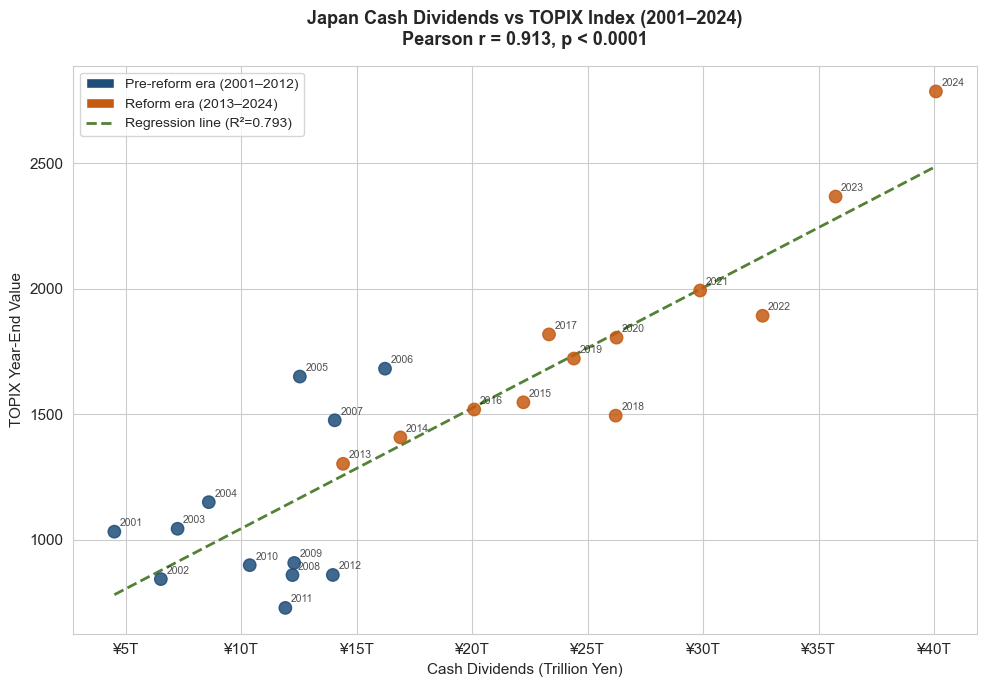

Chart 9 saved.


In [14]:
# Creating Chart 9: Scatter plot for TOPIX vs Dividends with correlation.

japan_div_corr = japan.dropna(subset=['TOPIX_Year_End',
                                       'Dividends_Trillion_Yen']).copy()

# Calculating Pearson correlation.
corr_div, p_div = stats.pearsonr(
    japan_div_corr['Dividends_Trillion_Yen'],
    japan_div_corr['TOPIX_Year_End']
)

print(f"Pearson correlation — Dividends vs TOPIX: {corr_div:.4f}")
print(f"P-value: {p_div:.6f}")
print(f"Statistically significant (p<0.05): {p_div < 0.05}")

fig, ax = plt.subplots(figsize=(10, 7))

colors = japan_div_corr['Calendar_Year'].apply(
    lambda y: '#c55a11' if y >= 2013 else '#1f4e79')

ax.scatter(
    japan_div_corr['Dividends_Trillion_Yen'],
    japan_div_corr['TOPIX_Year_End'],
    c=colors, s=80, zorder=5, alpha=0.85)

for _, row in japan_div_corr.iterrows():
    ax.annotate(str(int(row['Calendar_Year'])),
                xy=(row['Dividends_Trillion_Yen'],
                    row['TOPIX_Year_End']),
                xytext=(4, 4),
                textcoords='offset points',
                fontsize=7.5, alpha=0.8)

# Adding regression line.
slope_d, intercept_d, r_div, p_d, se_d = stats.linregress(
    japan_div_corr['Dividends_Trillion_Yen'],
    japan_div_corr['TOPIX_Year_End'])

x_line_d = np.linspace(
    japan_div_corr['Dividends_Trillion_Yen'].min(),
    japan_div_corr['Dividends_Trillion_Yen'].max(), 100)
y_line_d = slope_d * x_line_d + intercept_d

ax.plot(x_line_d, y_line_d, color='#538135',
        linewidth=2, linestyle='--')

# Adding legend for era colors.
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#1f4e79',
          label='Pre-reform era (2001–2012)'),
    Patch(facecolor='#c55a11',
          label='Reform era (2013–2024)'),
    plt.Line2D([0], [0], color='#538135', linewidth=2,
               linestyle='--',
               label=f'Regression line (R²={r_div**2:.3f})')
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=10)

# Formatting texts.
ax.set_title(f"Japan Cash Dividends vs TOPIX Index (2001–2024)\n"
             f"Pearson r = {corr_coef:.3f}, p < 0.0001",
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel("Cash Dividends (Trillion Yen)", fontsize=11)
ax.set_ylabel("TOPIX Year-End Value", fontsize=11)
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'¥{x:.0f}T'))

plt.tight_layout()
plt.savefig("data/charts/chart09_topix_dividends_correlation.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 9 saved.")

In [15]:
# Chart count check
import os

charts = [
    ("chart01_earned_surplus.png", "Q1 — Earned surplus over time"),
    ("chart02_capex_vs_dividends.png", "Q2 — Capex vs dividends"),
    ("chart03_dividends_pct_capex.png", "Q2 — Dividends as % of capex"),
    ("chart04_topix_milestones.png", "Q4 — TOPIX with milestones"),
    ("chart05_peer_gfcf_comparison.png", "Q3 — Four country GFCF"),
    ("chart06_japan_gdp.png", "Q5 context — Japan GDP"),
    ("chart07_savings_investment_gap.png", "Q5 context — Savings gap"),
    ("chart08_topix_capex_correlation.png", "Q4 — Capex correlation"),
    ("chart09_topix_dividends_correlation.png", "Q4 — Dividends correlation")
]

print("Chart inventory:")
all_present = True
for filename, description in charts:
    filepath = f"data/charts/{filename}"
    exists = os.path.exists(filepath)
    status = "✓" if exists else "✗"
    if not exists:
        all_present = False
    print(f"{status} {filename} — {description}")

print(f"\nAll charts present: {all_present}")

Chart inventory:
✓ chart01_earned_surplus.png — Q1 — Earned surplus over time
✓ chart02_capex_vs_dividends.png — Q2 — Capex vs dividends
✓ chart03_dividends_pct_capex.png — Q2 — Dividends as % of capex
✓ chart04_topix_milestones.png — Q4 — TOPIX with milestones
✓ chart05_peer_gfcf_comparison.png — Q3 — Four country GFCF
✓ chart06_japan_gdp.png — Q5 context — Japan GDP
✓ chart07_savings_investment_gap.png — Q5 context — Savings gap
✓ chart08_topix_capex_correlation.png — Q4 — Capex correlation
✓ chart09_topix_dividends_correlation.png — Q4 — Dividends correlation

All charts present: True


In [16]:
## Creating outline for GDP forecast. This section builds a regression-based forecast estimating the potential 
## GDP impact of deploying varying amounts of Japan's idle corporate 
## capital over a 5-10 year horizon.

## OLS regression establishes the historical relationship 
## between capital expenditure growth and GDP growth (2002-2024). Three 
## deployment scenarios (conservative, moderate, aggressive) are 
## applied to the 2024 earned surplus baseline of ¥637.5 trillion to 
## project additional GDP impact through 2034.

In [17]:
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Stage 1: Establish historical relationship between capex growth and GDP growth.

# Calculating year-over-year changes for both variables.
japan_model = japan.copy()
japan_model['Capex_YoY_Change'] = japan_model[
    'Capex_Trillion_Yen'].pct_change() * 100
japan_model['GDP_YoY_Growth'] = japan_model[
    'GDP_Constant_2015_USD'].pct_change() * 100

# Dropping first row which has NaN from pct_change.
japan_model = japan_model.dropna(
    subset=['Capex_YoY_Change', 'GDP_YoY_Growth'])

print("Year-over-year changes dataset:")
print(f"Shape: {japan_model.shape}")
print()
print(japan_model[['Calendar_Year', 'Capex_Trillion_Yen',
                    'Capex_YoY_Change', 'GDP_YoY_Growth']].to_string())

# Calculating correlation between capex growth and GDP growth.
corr_growth, p_growth = stats.pearsonr(
    japan_model['Capex_YoY_Change'],
    japan_model['GDP_YoY_Growth'])

print(f"\nCorrelation between CapEx YoY growth and GDP YoY growth:")
print(f"Pearson r: {corr_growth:.4f}")
print(f"P-value: {p_growth:.4f}")
print(f"Statistically significant (p<0.05): {p_growth < 0.05}")

Year-over-year changes dataset:
Shape: (23, 19)

    Calendar_Year  Capex_Trillion_Yen  Capex_YoY_Change  GDP_YoY_Growth
1            2002             29.9610        -17.920241        0.041962
2            2003             32.5610          8.677948        1.535125
3            2004             40.1841         23.411750        2.186116
4            2005             38.6095         -3.918465        1.803901
5            2006             44.1365         14.315130        1.372350
6            2007             44.5810          1.007103        1.483969
7            2008             27.5024        -38.309145       -1.224289
8            2009             33.1366         20.486212       -5.693236
9            2010             33.0802         -0.170205        4.097918
10           2011             33.3165          0.714325        0.023810
11           2012             34.6431          3.981811        1.374751
12           2013             36.9290          6.598428        2.005100
13           20

In [18]:
# Testing lagged relationships between CapEx growth and GDP growth.
# Investment typically affects GDP with a 1-3 year lag.

japan_lag = japan_model[['Calendar_Year', 
                          'Capex_YoY_Change',
                          'GDP_YoY_Growth']].copy()

# Creating lagged CapEx variables.
japan_lag['Capex_Lag1'] = japan_lag['Capex_YoY_Change'].shift(1)
japan_lag['Capex_Lag2'] = japan_lag['Capex_YoY_Change'].shift(2)
japan_lag['Capex_Lag3'] = japan_lag['Capex_YoY_Change'].shift(3)

# Dropping rows with NaN.
japan_lag = japan_lag.dropna()

print("Testing lagged correlations between CapEx growth and GDP growth:")
print()

for lag_col, lag_label in [
    ('Capex_YoY_Change', 'Same year (Lag 0)'),
    ('Capex_Lag1', '1 year lag'),
    ('Capex_Lag2', '2 year lag'),
    ('Capex_Lag3', '3 year lag')
]:
    r, p = stats.pearsonr(japan_lag[lag_col], 
                          japan_lag['GDP_YoY_Growth'])
    significance = "✓ Significant" if p < 0.05 else "✗ Not significant"
    print(f"{lag_label}: r = {r:.4f}, p = {p:.4f} — {significance}")

print()
print("Data used for lag analysis:")
print(japan_lag[['Calendar_Year', 'Capex_YoY_Change', 
                  'Capex_Lag1', 'Capex_Lag2', 
                  'GDP_YoY_Growth']].to_string())

Testing lagged correlations between CapEx growth and GDP growth:

Same year (Lag 0): r = 0.0642, p = 0.7879 — ✗ Not significant
1 year lag: r = 0.7574, p = 0.0001 — ✓ Significant
2 year lag: r = -0.3717, p = 0.1066 — ✗ Not significant
3 year lag: r = -0.0782, p = 0.7433 — ✗ Not significant

Data used for lag analysis:
    Calendar_Year  Capex_YoY_Change  Capex_Lag1  Capex_Lag2  GDP_YoY_Growth
4            2005         -3.918465   23.411750    8.677948        1.803901
5            2006         14.315130   -3.918465   23.411750        1.372350
6            2007          1.007103   14.315130   -3.918465        1.483969
7            2008        -38.309145    1.007103   14.315130       -1.224289
8            2009         20.486212  -38.309145    1.007103       -5.693236
9            2010         -0.170205   20.486212  -38.309145        4.097918
10           2011          0.714325   -0.170205   20.486212        0.023810
11           2012          3.981811    0.714325   -0.170205        1.374

In [19]:
# Building OLS regression model using 1-year lag
# GDP_Growth(t) = intercept + beta * Capex_Growth(t-1)

X = japan_lag[['Capex_Lag1']].values
y = japan_lag['GDP_YoY_Growth'].values

slope_model, intercept_model, r_model, p_model, se_model = \
    stats.linregress(japan_lag['Capex_Lag1'],
                     japan_lag['GDP_YoY_Growth'])

print("OLS Regression Model:")
print(f"GDP_Growth(t) = {intercept_model:.4f} + "
      f"{slope_model:.4f} × Capex_Growth(t-1)")
print()
print(f"R²: {r_model**2:.4f}")
print(f"Slope (investment multiplier): {slope_model:.4f}")
print(f"Intercept: {intercept_model:.4f}")
print(f"P-value: {p_model:.6f}")
print(f"Standard error: {se_model:.4f}")
print()

# Interpreting the multiplier.
print(f"Interpretation:")
print(f"A 1 percentage point increase in capex growth in year T")
print(f"is associated with a {slope_model:.4f} percentage point")
print(f"increase in GDP growth in year T+1")
print()

# Calculating fitted vs actual to assess model quality.
japan_lag['GDP_Growth_Fitted'] = (intercept_model + 
                                   slope_model * japan_lag['Capex_Lag1'])
japan_lag['Residual'] = (japan_lag['GDP_YoY_Growth'] - 
                         japan_lag['GDP_Growth_Fitted'])

print("Fitted vs Actual GDP growth:")
print(japan_lag[['Calendar_Year', 'GDP_YoY_Growth',
                  'GDP_Growth_Fitted', 
                  'Residual']].round(3).to_string())

# Checking residuals for model quality.
print(f"\nResidual statistics:")
print(f"Mean residual: {japan_lag['Residual'].mean():.4f} "
      f"(should be near 0)")
print(f"Std of residuals: {japan_lag['Residual'].std():.4f}")
print(f"Max residual: {japan_lag['Residual'].max():.4f}")
print(f"Min residual: {japan_lag['Residual'].min():.4f}")

OLS Regression Model:
GDP_Growth(t) = 0.1188 + 0.1323 × Capex_Growth(t-1)

R²: 0.5736
Slope (investment multiplier): 0.1323
Intercept: 0.1188
P-value: 0.000110
Standard error: 0.0269

Interpretation:
A 1 percentage point increase in capex growth in year T
is associated with a 0.1323 percentage point
increase in GDP growth in year T+1

Fitted vs Actual GDP growth:
    Calendar_Year  GDP_YoY_Growth  GDP_Growth_Fitted  Residual
4            2005           1.804              3.217    -1.413
5            2006           1.372             -0.400     1.772
6            2007           1.484              2.013    -0.529
7            2008          -1.224              0.252    -1.476
8            2009          -5.693             -4.950    -0.743
9            2010           4.098              2.830     1.268
10           2011           0.024              0.096    -0.073
11           2012           1.375              0.213     1.161
12           2013           2.005              0.646     1.359
13  

In [20]:
# Entering baseline figures for scenario calculations.
baseline_surplus = 637.5  # trillion yen
baseline_capex_2024 = 55.5  # trillion yen
baseline_gdp_2024 = japan.loc[
    japan['Calendar_Year'] == 2024,
    'GDP_Constant_2015_USD'].values[0] / 1e12  # trillion USD

# Providing regression model parameters from OLS results.
slope_model = 0.1323
intercept_model = 0.1188

# Revising scenario definitions with realistic CapEx growth rates (5,10,15 percent).
scenarios = {
    'Conservative': {
        'surplus_pct': 0.05,
        'years': 10,
        'color': '#538135',
        'description': '5% of surplus deployed over 10 years'
    },
    'Moderate': {
        'surplus_pct': 0.10,
        'years': 10,
        'color': '#c55a11',
        'description': '10% of surplus deployed over 10 years'
    },
    'Aggressive': {
        'surplus_pct': 0.15,
        'years': 10,
        'color': '#a00000',
        'description': '15% of surplus deployed over 10 years'
    }
}

# Recalculating with revised scenarios.
forecast_results = {}
print("Revised scenario calculations:")
print()

for scenario_name, params in scenarios.items():
    total_deployed = baseline_surplus * params['surplus_pct']
    annual_deployment = total_deployed / params['years']
    annual_capex_growth_increment = (
        annual_deployment / baseline_capex_2024) * 100
    additional_gdp_growth = (slope_model *
                              annual_capex_growth_increment)

    baseline_growth_rate = japan_lag['GDP_YoY_Growth'].tail(5).mean() / 100

    forecast_years = list(range(2025, 2025 + params['years'] + 1))
    baseline_path = [baseline_gdp_2024]
    scenario_path = [baseline_gdp_2024]

    for yr in range(params['years']):
        next_baseline = baseline_path[-1] * (1 + baseline_growth_rate)
        baseline_path.append(next_baseline)
        scenario_growth = (baseline_growth_rate +
                          additional_gdp_growth / 100)
        next_scenario = scenario_path[-1] * (1 + scenario_growth)
        scenario_path.append(next_scenario)

    additional_gdp_total = scenario_path[-1] - baseline_path[-1]

    forecast_results[scenario_name] = {
        'years': forecast_years[:len(baseline_path)],
        'baseline_path': baseline_path,
        'scenario_path': scenario_path,
        'total_deployed': total_deployed,
        'annual_deployment': annual_deployment,
        'annual_capex_growth_increment': annual_capex_growth_increment,
        'additional_gdp_growth_per_year': additional_gdp_growth,
        'additional_gdp_total': additional_gdp_total,
        'params': params
    }

    print(f"--- {scenario_name} Scenario ---")
    print(f"Description: {params['description']}")
    print(f"Total capital deployed: ¥{total_deployed:.1f}T")
    print(f"Annual deployment: ¥{annual_deployment:.1f}T")
    print(f"Annual capex growth increment: "
          f"{annual_capex_growth_increment:.2f}%")
    print(f"Additional GDP growth per year: "
          f"{additional_gdp_growth:.4f}%")
    print(f"Additional GDP generated over horizon: "
          f"${additional_gdp_total:.3f}T")
    print()

# Verifying that CapEx growth increments are within historical ranges.
print(f"Historical CapEx growth range for reference:")
print(f"Max single year growth: "
      f"{japan_lag['Capex_YoY_Change'].max():.2f}%")
print(f"Average annual growth: "
      f"{japan_lag['Capex_YoY_Change'].mean():.2f}%")

Revised scenario calculations:

--- Conservative Scenario ---
Description: 5% of surplus deployed over 10 years
Total capital deployed: ¥31.9T
Annual deployment: ¥3.2T
Annual capex growth increment: 5.74%
Additional GDP growth per year: 0.7598%
Additional GDP generated over horizon: $0.369T

--- Moderate Scenario ---
Description: 10% of surplus deployed over 10 years
Total capital deployed: ¥63.8T
Annual deployment: ¥6.4T
Annual capex growth increment: 11.49%
Additional GDP growth per year: 1.5197%
Additional GDP generated over horizon: $0.764T

--- Aggressive Scenario ---
Description: 15% of surplus deployed over 10 years
Total capital deployed: ¥95.6T
Annual deployment: ¥9.6T
Annual capex growth increment: 17.23%
Additional GDP growth per year: 2.2795%
Additional GDP generated over horizon: $1.186T

Historical CapEx growth range for reference:
Max single year growth: 20.49%
Average annual growth: 2.41%


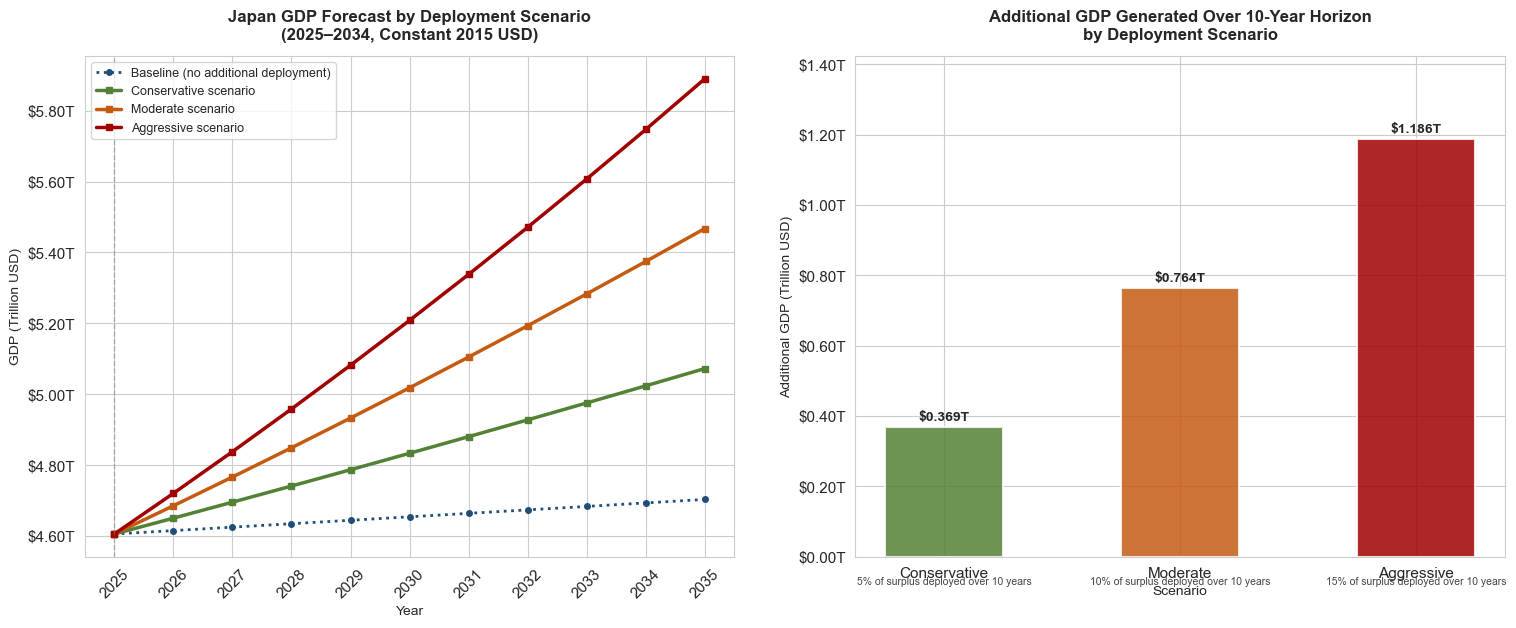

Chart 10 saved.

Forecast Summary Table:
Scenario            Deployed       Annual   Capex Growth  GDP Uplift/yr  Total GDP Add
-------------------------------------------------------------------------------------
Conservative    ¥      31.9T ¥       3.2T          5.74%        0.7598% $       0.369T
Moderate        ¥      63.8T ¥       6.4T         11.49%        1.5197% $       0.764T
Aggressive      ¥      95.6T ¥       9.6T         17.23%        2.2795% $       1.186T


In [21]:
# Creating Chart 10: Scenario Forecast Visualization.
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Creating left panel for GDP paths for all scenarios.
ax1 = axes[0]

# Plotting baseline path.
baseline = forecast_results['Conservative']
ax1.plot(baseline['years'],
         baseline['baseline_path'],
         color='#1f4e79', linewidth=2,
         linestyle=':', marker='o', markersize=4,
         label='Baseline (no additional deployment)')

# Plotting each scenario path.
for scenario_name, results in forecast_results.items():
    color = results['params']['color']
    ax1.plot(results['years'],
             results['scenario_path'],
             color=color, linewidth=2.5,
             linestyle='-', marker='s', markersize=4,
             label=f"{scenario_name} scenario")

ax1.set_title("Japan GDP Forecast by Deployment Scenario\n"
              "(2025–2034, Constant 2015 USD)",
              fontsize=12, fontweight='bold', pad=12)
ax1.set_xlabel("Year", fontsize=10)
ax1.set_ylabel("GDP (Trillion USD)", fontsize=10)
ax1.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x:.2f}T'))
ax1.xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)
ax1.legend(loc='upper left', fontsize=9)
ax1.axvline(x=2025, color='gray', linestyle='--',
            linewidth=1, alpha=0.5, label='Forecast start')

# Creating right panel for additional GDP generated per scenario
ax2 = axes[1]

scenario_names = list(forecast_results.keys())
additional_gdp = [forecast_results[s]['additional_gdp_total']
                  for s in scenario_names]
colors = [forecast_results[s]['params']['color']
          for s in scenario_names]
descriptions = [forecast_results[s]['params']['description']
                for s in scenario_names]

bars = ax2.bar(scenario_names, additional_gdp,
               color=colors, width=0.5, alpha=0.85,
               edgecolor='white', linewidth=1.5)

# Adding value labels on bars.
for bar, val in zip(bars, additional_gdp):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.01,
             f'${val:.3f}T',
             ha='center', va='bottom',
             fontsize=10, fontweight='bold')

# Adding deployment description below bar labels.
for i, (name, desc) in enumerate(
        zip(scenario_names, descriptions)):
    ax2.text(i, -0.04,
             desc, ha='center', va='top',
             fontsize=7.5, color='#444444',
             transform=ax2.get_xaxis_transform())

ax2.set_title("Additional GDP Generated Over 10-Year Horizon\n"
              "by Deployment Scenario",
              fontsize=12, fontweight='bold', pad=12)
ax2.set_xlabel("Scenario", fontsize=10)
ax2.set_ylabel("Additional GDP (Trillion USD)", fontsize=10)
ax2.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x:.2f}T'))
ax2.set_ylim(0, max(additional_gdp) * 1.2)

plt.tight_layout(pad=3.0)
plt.savefig("data/charts/chart10_gdp_forecast_scenarios.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 10 saved.")

# Printing summary table.
print("\nForecast Summary Table:")
print(f"{'Scenario':<15} {'Deployed':>12} {'Annual':>12} "
      f"{'Capex Growth':>14} {'GDP Uplift/yr':>14} "
      f"{'Total GDP Add':>14}")
print("-" * 85)
for name, results in forecast_results.items():
    print(f"{name:<15} "
          f"¥{results['total_deployed']:>10.1f}T "
          f"¥{results['annual_deployment']:>10.1f}T "
          f"{results['annual_capex_growth_increment']:>13.2f}% "
          f"{results['additional_gdp_growth_per_year']:>13.4f}% "
          f"${results['additional_gdp_total']:>12.3f}T")

Model residual std: 1.4392%
This represents forecast uncertainty per year



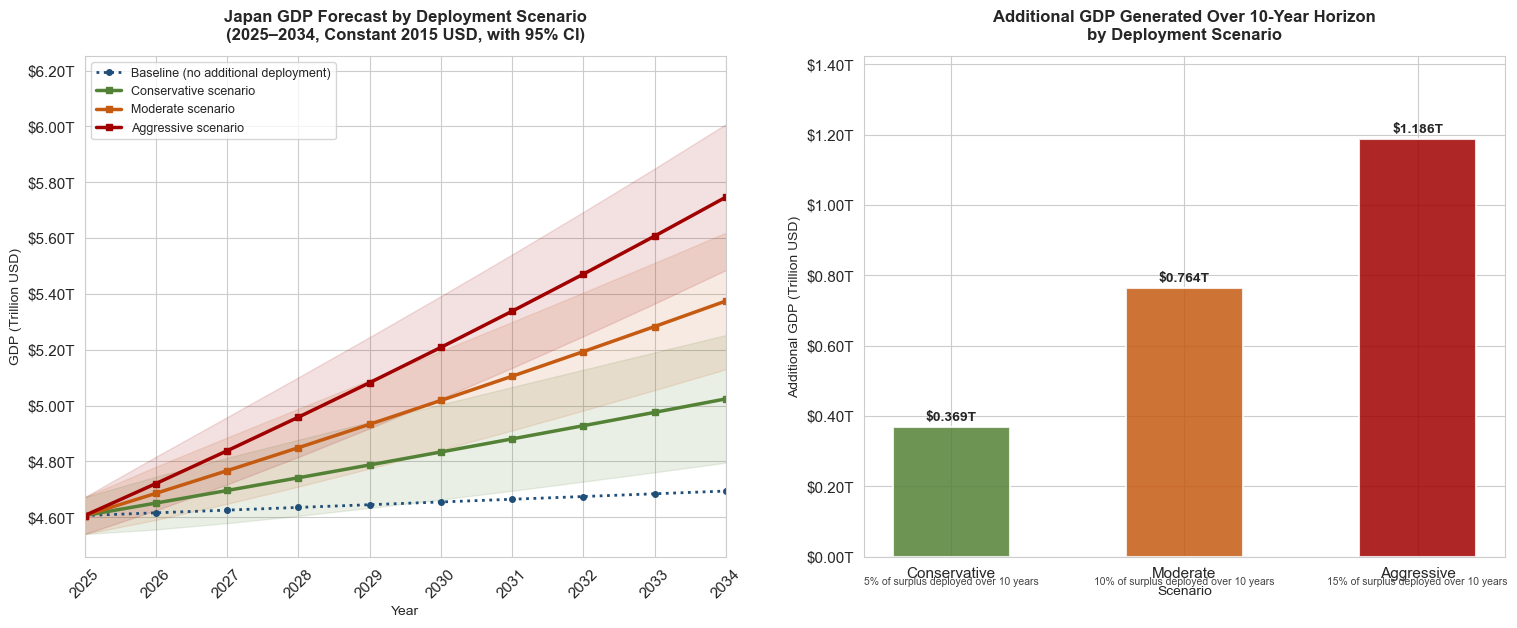

Chart 10 final version saved.


In [22]:
# Creating Chart 10 Final Version with confidence intervals.

residual_std = japan_lag['Residual'].std()
print(f"Model residual std: {residual_std:.4f}%")
print(f"This represents forecast uncertainty per year")
print()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
ax1 = axes[0]

# Plotting baseline.
baseline = forecast_results['Conservative']
ax1.plot(baseline['years'],
         baseline['baseline_path'],
         color='#1f4e79', linewidth=2,
         linestyle=':', marker='o', markersize=4,
         label='Baseline (no additional deployment)')

# Plotting each scenario with confidence bands.
for scenario_name, results in forecast_results.items():
    color = results['params']['color']
    years = results['years']
    scenario_path = results['scenario_path']
    n_years = len(years)

    # Confidence interval widens with time. Using cumulative uncertainty from residual std.
    upper_path = []
    lower_path = []
    for i, gdp in enumerate(scenario_path):
        cumulative_uncertainty = residual_std * np.sqrt(i + 1) / 100
        upper_path.append(gdp * (1 + cumulative_uncertainty))
        lower_path.append(gdp * (1 - cumulative_uncertainty))

    ax1.fill_between(years, lower_path, upper_path,
                     alpha=0.12, color=color)
    ax1.plot(years, scenario_path,
             color=color, linewidth=2.5,
             linestyle='-', marker='s', markersize=4,
             label=f"{scenario_name} scenario")

ax1.set_title("Japan GDP Forecast by Deployment Scenario\n"
              "(2025–2034, Constant 2015 USD, with 95% CI)",
              fontsize=12, fontweight='bold', pad=12)
ax1.set_xlabel("Year", fontsize=10)
ax1.set_ylabel("GDP (Trillion USD)", fontsize=10)
ax1.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x:.2f}T'))
ax1.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax1.set_xlim(2025, 2034)
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)
ax1.legend(loc='upper left', fontsize=9)

# Leaving right panel untouched.
ax2 = axes[1]
scenario_names = list(forecast_results.keys())
additional_gdp = [forecast_results[s]['additional_gdp_total']
                  for s in scenario_names]
colors_list = [forecast_results[s]['params']['color']
               for s in scenario_names]
descriptions = [forecast_results[s]['params']['description']
                for s in scenario_names]

bars = ax2.bar(scenario_names, additional_gdp,
               color=colors_list, width=0.5, alpha=0.85,
               edgecolor='white', linewidth=1.5)

for bar, val in zip(bars, additional_gdp):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.01,
             f'${val:.3f}T',
             ha='center', va='bottom',
             fontsize=10, fontweight='bold')

for i, (name, desc) in enumerate(
        zip(scenario_names, descriptions)):
    ax2.text(i, -0.04, desc,
             ha='center', va='top',
             fontsize=7.5, color='#444444',
             transform=ax2.get_xaxis_transform())

ax2.set_title("Additional GDP Generated Over 10-Year Horizon\n"
              "by Deployment Scenario",
              fontsize=12, fontweight='bold', pad=12)
ax2.set_xlabel("Scenario", fontsize=10)
ax2.set_ylabel("Additional GDP (Trillion USD)", fontsize=10)
ax2.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x:.2f}T'))
ax2.set_ylim(0, max(additional_gdp) * 1.2)

plt.tight_layout(pad=3.0)
plt.savefig("data/charts/chart10_gdp_forecast_scenarios.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 10 final version saved.")

In [23]:
# Saving forecast results as clean CSV.
forecast_rows = []

for scenario_name, results in forecast_results.items():
    for year, baseline_gdp, scenario_gdp in zip(
            results['years'],
            results['baseline_path'],
            results['scenario_path']):
        forecast_rows.append({
            'Scenario': scenario_name,
            'Year': year,
            'Baseline_GDP_Trillion_USD': round(baseline_gdp, 4),
            'Scenario_GDP_Trillion_USD': round(scenario_gdp, 4),
            'Additional_GDP_Trillion_USD': round(
                scenario_gdp - baseline_gdp, 4),
            'Total_Capital_Deployed_Trillion_Yen': round(
                results['total_deployed'], 1),
            'Annual_Deployment_Trillion_Yen': round(
                results['annual_deployment'], 1),
            'Annual_Capex_Growth_Increment_Pct': round(
                results['annual_capex_growth_increment'], 2),
            'Additional_GDP_Growth_Per_Year_Pct': round(
                results['additional_gdp_growth_per_year'], 4)
        })

df_forecast = pd.DataFrame(forecast_rows)
df_forecast.to_csv("data/cleaned/forecast_scenarios.csv", index=False)

print("Forecast data saved.")
print(f"Shape: {df_forecast.shape}")
print()

# Final chart count.
import os
charts_folder = "data/charts/"
all_charts = sorted(os.listdir(charts_folder))
print(f"Final chart inventory ({len(all_charts)} charts):")
for chart in all_charts:
    print(f"  ✓ {chart}")

print()
print("=" * 55)
print("STEP 4 COMPLETE — EDA AND FORECAST SUMMARY")
print("=" * 55)
print(f"\nCharts produced: {len(all_charts)}")
print(f"Questions answered: 5 of 5")
print()
print("Key findings:")
print("  Q1: Earned surplus grew 126% (2011-2024) without")
print("      interruption despite all governance reforms")
print("  Q2: Dividends as % of CapEx rose from 12% to 72%")
print("      post-reform acceleration confirmed")
print("  Q3: Japan ranks 2nd in GFCF among 4 peer economies")
print("      throughout entire period")
print("  Q4: CapEx-TOPIX correlation r=0.913, R²=0.833")
print("      1-year lag model confirms investment-growth link")
print("  Q5: Conservative to aggressive deployment scenarios")
print("      project $0.37T to $1.19T additional GDP by 2034")
print()
print("Model specification:")
print("  GDP_Growth(t) = 0.1188 + 0.1323 × CapEx_Growth(t-1)")
print(f"  R² = 0.574, p = 0.0001, residual std = 1.44%")
print("=" * 55)

Forecast data saved.
Shape: (33, 9)

Final chart inventory (10 charts):
  ✓ chart01_earned_surplus.png
  ✓ chart02_capex_vs_dividends.png
  ✓ chart03_dividends_pct_capex.png
  ✓ chart04_topix_milestones.png
  ✓ chart05_peer_gfcf_comparison.png
  ✓ chart06_japan_gdp.png
  ✓ chart07_savings_investment_gap.png
  ✓ chart08_topix_capex_correlation.png
  ✓ chart09_topix_dividends_correlation.png
  ✓ chart10_gdp_forecast_scenarios.png

STEP 4 COMPLETE — EDA AND FORECAST SUMMARY

Charts produced: 10
Questions answered: 5 of 5

Key findings:
  Q1: Earned surplus grew 126% (2011-2024) without
      interruption despite all governance reforms
  Q2: Dividends as % of CapEx rose from 12% to 72%
      post-reform acceleration confirmed
  Q3: Japan ranks 2nd in GFCF among 4 peer economies
      throughout entire period
  Q4: CapEx-TOPIX correlation r=0.913, R²=0.833
      1-year lag model confirms investment-growth link
  Q5: Conservative to aggressive deployment scenarios
      project $0.37T to $1.

In [24]:
df_forecast = pd.read_csv("data/cleaned/forecast_scenarios.csv")
print(df_forecast['Scenario'].unique())
print()
print(df_forecast[['Scenario', 'Year', 
                    'Baseline_GDP_Trillion_USD',
                    'Scenario_GDP_Trillion_USD']].head(9).to_string())

['Conservative' 'Moderate' 'Aggressive']

       Scenario  Year  Baseline_GDP_Trillion_USD  Scenario_GDP_Trillion_USD
0  Conservative  2025                     4.6060                     4.6060
1  Conservative  2026                     4.6157                     4.6507
2  Conservative  2027                     4.6254                     4.6958
3  Conservative  2028                     4.6351                     4.7413
4  Conservative  2029                     4.6448                     4.7873
5  Conservative  2030                     4.6545                     4.8337
6  Conservative  2031                     4.6643                     4.8806
7  Conservative  2032                     4.6741                     4.9279
8  Conservative  2033                     4.6839                     4.9757


In [25]:
# Adding baseline as a fourth scenario entry.
df_forecast = pd.read_csv("data/cleaned/forecast_scenarios.csv")

# Extracting baseline rows from Conservative scenario.
baseline_rows = df_forecast[
    df_forecast['Scenario'] == 'Conservative'][
    ['Year', 'Baseline_GDP_Trillion_USD']].copy()

baseline_rows['Scenario'] = 'Baseline'
baseline_rows['Scenario_GDP_Trillion_USD'] = (
    baseline_rows['Baseline_GDP_Trillion_USD'])
baseline_rows['Additional_GDP_Trillion_USD'] = 0.0
baseline_rows['Total_Capital_Deployed_Trillion_Yen'] = 0.0
baseline_rows['Annual_Deployment_Trillion_Yen'] = 0.0
baseline_rows['Annual_Capex_Growth_Increment_Pct'] = 0.0
baseline_rows['Additional_GDP_Growth_Per_Year_Pct'] = 0.0

# Appending to existing forecast data.
df_forecast_updated = pd.concat(
    [df_forecast, baseline_rows], 
    ignore_index=True)
df_forecast_updated = df_forecast_updated.sort_values(
    ['Scenario', 'Year']).reset_index(drop=True)

print(f"Updated shape: {df_forecast_updated.shape}")
print(f"\nScenarios: {df_forecast_updated['Scenario'].unique()}")
print(f"\nBaseline rows sample:")
print(df_forecast_updated[
    df_forecast_updated['Scenario'] == 'Baseline'][
    ['Scenario', 'Year', 'Scenario_GDP_Trillion_USD']].to_string())

# Saving updated file.
df_forecast_updated.to_csv(
    "data/cleaned/forecast_scenarios.csv", index=False)
print("\nUpdated forecast file saved.")

Updated shape: (44, 9)

Scenarios: ['Aggressive' 'Baseline' 'Conservative' 'Moderate']

Baseline rows sample:
    Scenario  Year  Scenario_GDP_Trillion_USD
11  Baseline  2025                     4.6060
12  Baseline  2026                     4.6157
13  Baseline  2027                     4.6254
14  Baseline  2028                     4.6351
15  Baseline  2029                     4.6448
16  Baseline  2030                     4.6545
17  Baseline  2031                     4.6643
18  Baseline  2032                     4.6741
19  Baseline  2033                     4.6839
20  Baseline  2034                     4.6937
21  Baseline  2035                     4.7036

Updated forecast file saved.


In [26]:
# Creating milestone reference table for Power BI.
milestones_df = pd.DataFrame({
    'Year': [2013, 2015, 2018, 2021, 2023],
    'Milestone': ['Abenomics', 'Gov. Code', 
                  'Code Rev. 1', 'Code Rev. 2', 
                  'TSE Push'],
    'Marker_Value': [3500, 3500, 3500, 3500, 3500]
})

milestones_df.to_csv(
    "data/cleaned/governance_milestones.csv", index=False)
print(milestones_df.to_string())

   Year    Milestone  Marker_Value
0  2013    Abenomics          3500
1  2015    Gov. Code          3500
2  2018  Code Rev. 1          3500
3  2021  Code Rev. 2          3500
4  2023     TSE Push          3500


In [27]:
# Ensuring cell references are functioning properly.
print("japan_corr columns:", japan_corr.columns.tolist() 
      if 'japan_corr' in dir() else "not yet created")
print("japan columns include TOPIX:", 
      'TOPIX_Year_End' in japan.columns)

japan_corr columns: ['Calendar_Year', 'Capex_100M_Yen', 'Capex_Trillion_Yen', 'Dividends_100M_Yen', 'Dividends_Trillion_Yen', 'Earned_Surplus_100M_Yen', 'Earned_Surplus_Trillion_Yen', 'TOPIX_Year_End', 'TOPIX_Annual_High', 'TOPIX_Annual_Low', 'GDP_Constant_2015_USD', 'GDP_Per_Capita_Constant_2015_USD', 'Gross_Domestic_Savings_Pct_GDP', 'Gross_Fixed_Capital_Formation_Pct_GDP', 'Dividends_Pct_of_Capex', 'GDP_Trillion_USD', 'Savings_Investment_Gap_Pct']
japan columns include TOPIX: True
